# 04. Module 2: schema and drift detection

Module 2 runs three checks. A structural check looks for columns that are dropped, renamed, or retyped. A statistical check uses the KS test for numeric columns and Chi-squared for categorical ones. A Random Forest classifier is then trained on the drift statistics.

A note on the experiment design, which matters for the methodology. The clean (label 0) batches for the Random Forest are sampled from the same period as the reference, days 1 to 3. This isolates the injected drift as the only signal. If the clean batches came from a later period they would carry natural temporal drift and confuse the classifier, which is itself a finding worth stating. The classifier is trained on injected drift at 5% and 10% and evaluated at 20% and 30% with different seeds. That reduces the circularity of training and testing on synthetic drift, though it does not remove it.

In [1]:
import sys, os
sys.path.append(os.path.abspath('../src'))
import numpy as np, pandas as pd
from preprocessing import temporal_split
from injection import inject_schema_drift
import module2_drift as m2
DATA_PATH = '../data/HI-Small_Trans.csv'

In [2]:
cols=['Timestamp','Amount Paid','Amount Received','Receiving Currency','Payment Currency','Payment Format']
df = pd.read_csv(DATA_PATH, usecols=cols)
ref, inc = temporal_split(df, reference_days=3, max_days=10)
ref_pool = ref.reset_index(drop=True)
reference = ref_pool.sample(50_000, random_state=42).reset_index(drop=True)
print('reference:', reference.shape[0], '| reference pool (days 1-3):', ref_pool.shape[0])

reference: 50000 | reference pool (days 1-3): 2076752


## Step 1: Structural check
Deterministic: catches dropped or added columns and dtype changes.

In [3]:
batch = ref_pool.sample(20_000, random_state=1).reset_index(drop=True)
print('clean vs clean :', m2.structural_check(reference, batch))
d_drop,_ = inject_schema_drift(batch, drop_column='Payment Format')
print('dropped column :', m2.structural_check(reference, d_drop))
d_type,_ = inject_schema_drift(batch, dtype_change=('Amount Paid', str))
print('dtype change   :', m2.structural_check(reference, d_type))

clean vs clean : {}
dropped column : {'dropped_columns': ['Payment Format']}
dtype change   : {'dtype_changes': {'Amount Paid': {'from': 'float64', 'to': 'str'}}}


## Step 2: Statistical check
KS for numeric, Chi-squared for categorical. Here the amount distribution is shifted to confirm that only the amount columns flag.

In [4]:
drifted = m2.inject_distribution_shift(batch, column='Amount Paid', rate=0.20, seed=7)
sc = m2.statistical_check(reference, drifted)
rows=[]
for col,v in sc.items():
    stat = v.get('ks_stat') if v['type']=='numeric' else v.get('chi2_stat')
    rows.append([col, v['type'], round(stat,3), format(v['p_value'],'.2g'), v['drifted']])
pd.DataFrame(rows, columns=['column','type','stat','p_value','drifted'])

,column,type,stat,p_value,drifted
0,Amount Paid,numeric,0.055,1.8e-38,True
1,Amount Received,numeric,0.004,0.94,False
2,Receiving Currency,categorical,11.612,0.64,False
3,Payment Currency,categorical,12.056,0.6,False
4,Payment Format,categorical,2.616,0.86,False


## Step 3: Random Forest drift classifier
Train at 5% and 10%, evaluate at 20% and 30% with different seeds. Clean batches come from the reference pool.

In [5]:
Xtr, ytr = m2.build_drift_dataset(reference, ref_pool, rates=[0.05,0.10], batch_size=20_000, n_per_rate=20, seed=42)
Xte, yte = m2.build_drift_dataset(reference, ref_pool, rates=[0.20,0.30], batch_size=20_000, n_per_rate=20, seed=999)
clf = m2.train_drift_classifier(Xtr, ytr)
res = m2.evaluate_drift_classifier(clf, Xte, yte)
print('train batches:', len(ytr), '| eval batches:', len(yte))
pd.DataFrame([{k:round(v,3) for k,v in res.items() if k!='confusion_matrix'}])

train batches: 80 | eval batches: 80


,precision,recall,f1,roc_auc
0,0.976,1.0,0.988,1.0


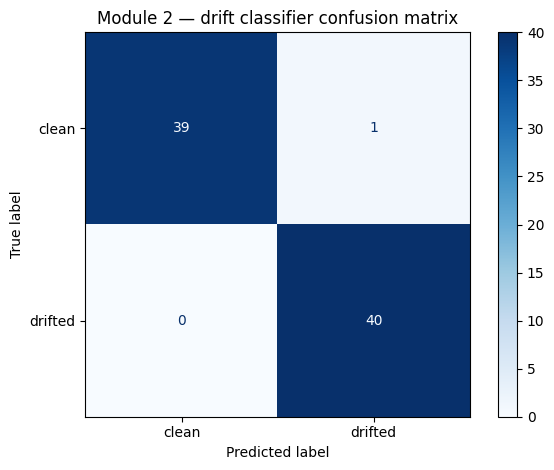

In [6]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay(np.array(res['confusion_matrix']), display_labels=['clean','drifted']).plot(cmap='Blues')
plt.title('Module 2 — drift classifier confusion matrix')
plt.tight_layout(); plt.savefig('../results/module2_confusion.png', dpi=120); plt.show()

## Step 4: RQ2 baseline, statistical tests alone vs the full Module 2
Research Question 2 asks whether the learned classifier improves on the two-sample tests on their own. The cell below scores the same evaluation batches two ways, so the comparison is fair: the statistical tests flag a batch when any column's p-value falls below 0.05, and the Random Forest scores the same batches from the drift statistics.

In [ ]:
# ---- RQ2: statistical tests alone vs the full learned Module 2 (same test batches) ----
from sklearn.metrics import roc_auc_score, f1_score

def statistical_only(reference_df, batch, alpha=0.05):
    """Two-sample tests only. Returns (drift score, binary decision).
    Score = 1 - smallest p-value across columns (higher = stronger drift)."""
    sc = m2.statistical_check(reference_df, batch)
    pvals = [v['p_value'] for v in sc.values()] or [1.0]
    min_p = min(pvals)
    return 1.0 - min_p, int(min_p < alpha)

# regenerate the SAME evaluation batches used for the classifier (rates 20%/30%, seed 999)
rng = np.random.default_rng(999)
rf_score, stat_score, stat_decision, labels = [], [], [], []
for rate in [0.20, 0.30]:
    for _ in range(20):
        b = ref_pool.sample(n=20_000, random_state=int(rng.integers(1e9)))
        rf_score.append(clf.predict_proba(m2.drift_feature_vector(reference, b).reshape(1, -1))[0, 1])
        s, dcn = statistical_only(reference, b); stat_score.append(s); stat_decision.append(dcn); labels.append(0)
        b = ref_pool.sample(n=20_000, random_state=int(rng.integers(1e9)))
        b = m2.inject_distribution_shift(b, column='Amount Paid', rate=rate, seed=int(rng.integers(1e9)))
        rf_score.append(clf.predict_proba(m2.drift_feature_vector(reference, b).reshape(1, -1))[0, 1])
        s, dcn = statistical_only(reference, b); stat_score.append(s); stat_decision.append(dcn); labels.append(1)

labels = np.array(labels)
rf_decision = (np.array(rf_score) >= 0.5).astype(int)
comparison = pd.DataFrame([
    {'Method': 'Statistical tests only (KS + Chi-squared)',
     'ROC-AUC': round(roc_auc_score(labels, stat_score), 3),
     'F1':      round(f1_score(labels, stat_decision), 3)},
    {'Method': 'Full Module 2 (learned Random Forest)',
     'ROC-AUC': round(roc_auc_score(labels, rf_score), 3),
     'F1':      round(f1_score(labels, rf_decision), 3)},
])
print(comparison.to_string(index=False))
comparison

## Reading the results

The structural check catches schema drift exactly, since it is a direct comparison and needs no model. The statistical check flags the shifted amount columns and correctly leaves the unchanged currencies alone. The Random Forest separates injected drift from clean batches with high F1. Because this is a controlled synthetic experiment, a high score is expected and has to be reported as such, with the circularity limitation stated plainly. What the result does show is that the three-step design catches all four drift types.